# ApexTracking - ML Pipeline Notebook
Tento notebook dokumentuje cely proces tvorby modelu pro projekt ApexTracking:
- puvod dat (vlastni sber pres Apex API),
- cisteni a transformace dat,
- trenink 3 modelu (rank, damage/game, win rate),
- evaluace a export modelu pro produkcni nasazeni.

Poznamka k provozu aplikace: finalni aplikace se spousti na Renderu (ne pres localhost).

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style="whitegrid")

def pick_dataset_path() -> Path:
    candidates = [Path("data/players.csv"), Path("data/players_ready.csv")]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError("Nenalezen data/players.csv ani data/players_ready.csv")

def clamp_series(s: pd.Series, low: float, high: float) -> pd.Series:
    return s.clip(lower=low, upper=high)

In [2]:
dataset_path = pick_dataset_path()
df = pd.read_csv(dataset_path)

print("Dataset:", dataset_path)
print("Rows:", len(df))
print("Columns:", len(df.columns))
display(df.head(3))

Dataset: data\players_ready.csv
Rows: 12004
Columns: 13


,player,uid,level,rank,rank_div,rank_score,kills,damage,headshots,games_played,wins,kdr,damage_per_game
0,monkey_nut_jr,1012158787321,449.0,Silver,2,4668.0,2511.0,520648.0,0.0,0.0,0.0,0.0,0.0
1,Nickmercs,1003944652988,133.0,Platinum,2,10764.0,4677.0,766507.0,0.0,0.0,0.0,0.0,0.0
2,Milcaz,2796566367,184.0,Silver,2,4008.0,45.0,146508.0,0.0,0.0,0.0,0.0,0.0


In [3]:
required_cols = [
    "level", "rank_score", "kills", "damage", "headshots",
    "games_played", "wins", "kdr", "damage_per_game", "rank"
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Chybi sloupce: {missing}")

# 1) Cisteni: rank nesmi byt null
df = df.dropna(subset=["rank"]).copy()

# 2) Transformace: numericke sloupce
num_cols = ["level", "rank_score", "kills", "damage", "headshots", "games_played", "wins", "kdr", "damage_per_game"]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0.0)

# 3) Filtrovani: odstraneni nevalidnich radku
df = df[df["games_played"] > 0].copy()
df = df[df["wins"] >= 0].copy()
df = df[df["wins"] <= df["games_played"]].copy()

# 4) Osetreni outlieru
df["kdr"] = clamp_series(df["kdr"], 0.0, 10.0)
df["damage_per_game"] = clamp_series(df["damage_per_game"], 0.0, 5000.0)

print("Rows po cisteni:", len(df))
print("Atributu pouzitych pro model:", 8)

Rows po cisteni: 9075
Atributu pouzitych pro model: 8


In [4]:
feature_columns = ["level", "rank_score", "kills", "damage", "headshots", "games_played", "wins", "kdr"]
X = df[feature_columns]

label_encoder = LabelEncoder()
y_rank = label_encoder.fit_transform(df["rank"].astype(str))

# Regresni target 1
y_damage = pd.to_numeric(df["damage_per_game"], errors="coerce").fillna(0.0)

# Regresni target 2
y_win_rate = (
    pd.to_numeric(df["wins"], errors="coerce").fillna(0.0)
    / pd.to_numeric(df["games_played"], errors="coerce").fillna(0.0).replace(0, 1)
).clip(lower=0.0, upper=1.0)

print("Rank classes:", sorted(df["rank"].astype(str).unique().tolist()))

Rank classes: ['Bronze', 'Diamond', 'Gold', 'Master', 'Platinum', 'Predator', 'Rookie', 'Silver', 'Unranked']


In [5]:
split_kwargs = {"test_size": 0.2, "random_state": 42}
class_counts = pd.Series(y_rank).value_counts()
can_stratify = len(class_counts) > 1 and class_counts.min() >= 2

if can_stratify:
    X_train, X_test, y_rank_train, y_rank_test, y_damage_train, y_damage_test, y_win_train, y_win_test = train_test_split(
        X, y_rank, y_damage, y_win_rate, stratify=y_rank, **split_kwargs
    )
else:
    X_train, X_test, y_rank_train, y_rank_test, y_damage_train, y_damage_test, y_win_train, y_win_test = train_test_split(
        X, y_rank, y_damage, y_win_rate, **split_kwargs
    )

rank_model = RandomForestClassifier(
    n_estimators=70,
    max_depth=12,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
 )
rank_model.fit(X_train, y_rank_train)
rank_pred = rank_model.predict(X_test)
rank_acc = accuracy_score(y_rank_test, rank_pred)

print(f"Rank accuracy: {rank_acc:.4f}")
print(classification_report(y_rank_test, rank_pred, target_names=label_encoder.classes_))

Rank accuracy: 0.8915
              precision    recall  f1-score   support

      Bronze       0.98      0.99      0.98       427
     Diamond       0.61      0.72      0.66       116
        Gold       0.90      0.88      0.89       423
      Master       0.66      0.60      0.62        42
    Platinum       0.79      0.79      0.79       263
    Predator       0.67      0.67      0.67         9
      Rookie       1.00      1.00      1.00        63
      Silver       0.95      0.93      0.94       457
    Unranked       1.00      1.00      1.00        15

    accuracy                           0.89      1815
   macro avg       0.84      0.84      0.84      1815
weighted avg       0.89      0.89      0.89      1815



Damage MAE: 40.65
Win rate MAE: 0.60 pp


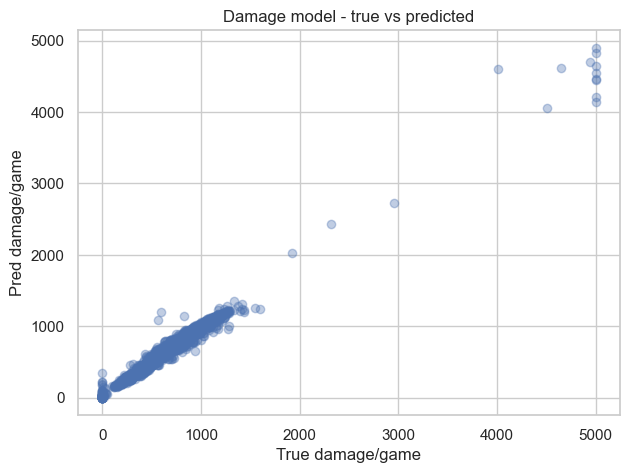

In [6]:
damage_model = RandomForestRegressor(
    n_estimators=70,
    max_depth=12,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1,
 )
damage_model.fit(X_train, y_damage_train)
damage_pred = damage_model.predict(X_test)
damage_mae = mean_absolute_error(y_damage_test, damage_pred)

win_rate_model = RandomForestRegressor(
    n_estimators=70,
    max_depth=12,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1,
 )
win_rate_model.fit(X_train, y_win_train)
win_pred = np.clip(win_rate_model.predict(X_test), 0.0, 1.0)
win_mae = mean_absolute_error(y_win_test, win_pred)

print(f"Damage MAE: {damage_mae:.2f}")
print(f"Win rate MAE: {win_mae * 100:.2f} pp")

plt.figure(figsize=(7, 5))
plt.scatter(y_damage_test, damage_pred, alpha=0.35)
plt.xlabel("True damage/game")
plt.ylabel("Pred damage/game")
plt.title("Damage model - true vs predicted")
plt.show()

In [ ]:
bundle = {
    "rank_model": rank_model,
    "damage_model": damage_model,
    "win_rate_model": win_rate_model,
    "label_encoder": label_encoder,
    "feature_columns": feature_columns,
}

out_path = Path("model/model.pkl")
out_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(bundle, out_path, compress=("xz", 3))

size_mb = out_path.stat().st_size / (1024 * 1024)
print(f"Saved: {out_path} ({size_mb:.2f} MB)")

# Quick sanity inference
sample = X_test.iloc[[0]].copy()
rank_idx = int(rank_model.predict(sample)[0])
rank_name = label_encoder.inverse_transform(np.array([rank_idx]))[0]
print("Sample rank:", rank_name)
print("Sample damage:", float(damage_model.predict(sample)[0]))
print("Sample win rate:", float(np.clip(win_rate_model.predict(sample)[0], 0.0, 1.0)))

Saved: model\model.pkl (5.27 MB)
Sample rank: Platinum
Sample damage: 902.2187384501278
Sample win rate: 0.17302760454173313


: 

## Deploy and Runtime (Render only)
Finalni aplikace se spousti na Renderu, ne na localhost.

Minimalni produkcni konfigurace:
- Build Command: `pip install -r requirements.txt`
- Start Command: `python -m src.web`
- Environment variables: `DATABASE_URL`, `APEX_API_KEY`, `FLASK_SECRET_KEY`

Tento notebook slouzi jako dokumentace tvorby modelu a evaluace.

## Data Collection (Notebook-only)
This section replaces the old script workflow (`collector.py` + `uid_harvester.py`).
Use the helper functions below to:
- collect rows by player names,
- harvest unique profiles by UID probing.

The web app still uses `src/apex_api.py` at runtime, but dataset collection is now driven from this notebook.

In [1]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path
import csv
import random
import time

from src.apex_api import (
    CollectorError,
    fetch_player_stats,
    fetch_player_stats_by_uid,
    is_row_usable,
    load_api_key,
    player_to_row,
 )

def collect_players_to_csv(
    players,
    out_csv='data/players.csv',
    platform='PC',
    sleep_seconds=0.25,
    min_level=25.0,
    min_kills=80.0,
    min_damage=20000.0,
    min_rank_score=1000.0,
    min_nonzero_metrics=3,
    allow_no_gameplay_signal=False,
 ):
    api_key = load_api_key()
    rows = []
    seen = set()

    for name in [str(p).strip() for p in players if str(p).strip()]:
        try:
            payload = fetch_player_stats(player=name, api_key=api_key, platform=platform)
            row = player_to_row(payload, requested_name=name)
            if not is_row_usable(
                row,
                min_level=min_level,
                min_kills=min_kills,
                min_damage=min_damage,
                min_rank_score=min_rank_score,
                min_nonzero_metrics=min_nonzero_metrics,
                require_gameplay_signal=not allow_no_gameplay_signal,
            ):
                continue

            key = str(row.get('uid', '')).strip() or str(row.get('player', '')).strip().lower()
            if key in seen:
                continue
            seen.add(key)
            rows.append(row)
            print(f'OK: {name}')
        except CollectorError as exc:
            print(f'SKIP {name}: {exc}')

        if sleep_seconds > 0:
            time.sleep(sleep_seconds)

    if not rows:
        raise RuntimeError('No rows collected.')

    out = Path(out_csv)
    out.parent.mkdir(parents=True, exist_ok=True)
    with out.open('w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
        writer.writeheader()
        writer.writerows(rows)

    print(f'Saved {len(rows)} rows to {out}')
    return rows

def harvest_uids_to_csv(
    target=1000,
    max_attempts=50000,
    out_csv='data/players.csv',
    seed_csv='data/players.csv',
    platform='PC',
    workers=4,
    request_timeout=20.0,
    checkpoint_every=25,
    min_level=25.0,
    min_kills=80.0,
    min_damage=20000.0,
    min_rank_score=1000.0,
    min_nonzero_metrics=3,
    allow_no_gameplay_signal=False,
 ):
    api_key = load_api_key()
    out = Path(out_csv)

    seeds = []
    if Path(seed_csv).exists():
        with Path(seed_csv).open('r', newline='', encoding='utf-8') as f:
            for r in csv.DictReader(f):
                uid = str(r.get('uid', '')).strip()
                if uid.isdigit():
                    seeds.append(int(uid))

    if not seeds:
        seeds = [2796574388, 1008248071359, 1008995227775, 1003944652988]

    rows = []
    collected = set()
    seen_probe = set()
    attempts = 0

    def candidate_uid():
        pivot = random.choice(seeds)
        return str(max(1, pivot + random.randint(-25000, 25000)))

    def fetch_one(uid):
        try:
            payload = fetch_player_stats_by_uid(uid=uid, api_key=api_key, platform=platform, timeout=request_timeout)
            row = player_to_row(payload)
            if not is_row_usable(
                row,
                min_level=min_level,
                min_kills=min_kills,
                min_damage=min_damage,
                min_rank_score=min_rank_score,
                min_nonzero_metrics=min_nonzero_metrics,
                require_gameplay_signal=not allow_no_gameplay_signal,
            ):
                return None
            return row
        except Exception:
            return None

    with ThreadPoolExecutor(max_workers=max(1, int(workers))) as ex:
        while len(rows) < int(target) and attempts < int(max_attempts):
            batch = []
            while len(batch) < max(1, workers * 2) and attempts < int(max_attempts):
                uid = candidate_uid()
                attempts += 1
                if uid in seen_probe:
                    continue
                seen_probe.add(uid)
                batch.append(uid)

            futures = [ex.submit(fetch_one, uid) for uid in batch]
            for fu in as_completed(futures):
                row = fu.result()
                if row is None:
                    continue
                uid = str(row.get('uid', '')).strip()
                if not uid or uid in collected:
                    continue
                collected.add(uid)
                rows.append(row)
                seeds.append(int(uid))

                if len(rows) % checkpoint_every == 0:
                    out.parent.mkdir(parents=True, exist_ok=True)
                    with out.open('w', newline='', encoding='utf-8') as f:
                        writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
                        writer.writeheader()
                        writer.writerows(rows)
                    print(f'Checkpoint: {len(rows)} rows after {attempts} attempts')

            if len(rows) >= int(target):
                break

    if not rows:
        raise RuntimeError('No UID rows harvested.')

    out.parent.mkdir(parents=True, exist_ok=True)
    with out.open('w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
        writer.writeheader()
        writer.writerows(rows)

    print(f'Harvest done: {len(rows)} rows after {attempts} attempts -> {out}')
    return rows

# Example usage:
## players = ['ImperialHal', 'iiTzTimmy', 'Aceu']
## collect_players_to_csv(players, out_csv='data/players.csv')

## harvest_uids_to_csv(target=500, max_attempts=20000, workers=6, out_csv='data/players.csv')